<figure>
   <IMG SRC="https://mamba-python.nl/images/logo_basis.png" WIDTH=125 ALIGN="right">
</figure>

# Geopandas
_developed by Davíd Brakenhoff & Onno Ebbens_
<hr>

This notebook shows some of the basic functionality of the geopandas module. Geopandas combines the power of shapefiles with the power of Pandas for working with large datasets.

### Contents<a id="top"></a>
1. [Install and import geopandas](#1)
2. [Reading shapefiles](#3)
3. [Viewing attribute table](#4)
4. [Geodataframe from DataFrame](#5)
5. [Plotting data](#plot)
6. [Add basemap to plot](#7)

## 1. [Install and import geopandas](#top)<a id="1"></a>

Geopandas is a package that is not included in the default conda packages. Therefore you have to install geopandas. The easiest way to this is by opening an Anaconda Prompt and run the command: `pip install geopandas`. If the installation was succesfull you can import geopandas using the code below.


In [2]:
import geopandas as gpd
import pandas as pd

## 2. [Reading shapefiles](#top)<a id="3"></a>
This is done using the `gpd.read_file()` function

In [3]:
fileName = r"data/Rotterdam_centraal.shp"
gdf = gpd.read_file(fileName)

## 3. [Viewing attribute table](#top)<a id="4"></a>
The attribute table is loaded as a GeoDataFrame which is similar to a `pandas.DataFrame`.

In [4]:
gdf

,id,geometry
0,1,"POLYGON ((91681.109 437839.912, 91914.843 4379..."
1,2,"POLYGON ((91662.632 437612.453, 91859.764 4376..."


Operations, such as `loc` and `sum()`, that you do on `pandas.DataFrames` are also available on `GeoDataFrames`. 

In [5]:
gdf.loc[1, "id"]

np.int64(2)

In [6]:
gdf["id"].sum()

np.int64(3)

#### Exercise 1<a name="ex1"></a>
In the `data` directory is a file named `nybb.shp`. Read the shapefile as a `GeoDataFrame` and have a look at the attribute table. What kind of data is in tihs shapefile?

<a href="#ans1">Answer Exercise 1</a>

#### Exercise 2<a name="ex2"></a>
One of the columns in the attribute table shows the surface area within a shape. Use the `idxmax()` method of pandas to find the shape and properties of the polygon with the biggest surface area.

<a href="#ans2">Answer Exercise 2</a>

## 4. [GeoDataFrame from DataFrame](#top)<a id="5"></a>

You can convert a DataFrame with x and y coördinates to a GeoDataFrame. First we load a dataframe with x and y coordinates in the columns `UTM_X` and `UTM_Y`.

In [7]:
df_turbines = pd.read_excel(r'data/turbines_ohvs.xlsx')
df_turbines.head()

,FID,OBJECTID,UTM_X,UTM_Y,NAAM,STATUS,OPMERKING,GEBIEDNR,TURBINE_NR,EIGENAAR,SE_ANNO_CAD_DATA
0,turbines_en_ohvs.fid--3797e2cd_170a1064346_-6ee1,173,701025.84,5992916.19,Buitengaats / Gemini I,In gebruik,turbine,12,U3,Gemini Buitengaats,NaN
1,turbines_en_ohvs.fid--3797e2cd_170a1064346_-6ee0,174,700778.49,5993553.95,Buitengaats / Gemini I,In gebruik,turbine,12,U4,Gemini Buitengaats,NaN
2,turbines_en_ohvs.fid--3797e2cd_170a1064346_-6edf,175,700533.22,5994191.92,Buitengaats / Gemini I,In gebruik,turbine,12,U5,Gemini Buitengaats,NaN
3,turbines_en_ohvs.fid--3797e2cd_170a1064346_-6ede,176,700286.86,5994830.97,Buitengaats / Gemini I,In gebruik,turbine,12,U6,Gemini Buitengaats,NaN
4,turbines_en_ohvs.fid--3797e2cd_170a1064346_-6edd,177,700039.92,5995468.90,Buitengaats / Gemini I,In gebruik,turbine,12,U7,Gemini Buitengaats,NaN


We use the `points_from_xy` function to convert the x and y coördinates in to a list of `POINT` geometries. Then we create a `GeoDataFrame` from the original `DataFrame` and the list of geometries we've just created. 

In [8]:
geometry = gpd.points_from_xy(df_turbines['UTM_X'], df_turbines['UTM_Y'])
gdf_turbines = gpd.GeoDataFrame(df_turbines, geometry=geometry)
gdf_turbines.head()

,FID,OBJECTID,UTM_X,UTM_Y,NAAM,STATUS,OPMERKING,GEBIEDNR,TURBINE_NR,EIGENAAR,SE_ANNO_CAD_DATA,geometry
0,turbines_en_ohvs.fid--3797e2cd_170a1064346_-6ee1,173,701025.84,5992916.19,Buitengaats / Gemini I,In gebruik,turbine,12,U3,Gemini Buitengaats,NaN,POINT (701025.84 5992916.19)
1,turbines_en_ohvs.fid--3797e2cd_170a1064346_-6ee0,174,700778.49,5993553.95,Buitengaats / Gemini I,In gebruik,turbine,12,U4,Gemini Buitengaats,NaN,POINT (700778.49 5993553.95)
2,turbines_en_ohvs.fid--3797e2cd_170a1064346_-6edf,175,700533.22,5994191.92,Buitengaats / Gemini I,In gebruik,turbine,12,U5,Gemini Buitengaats,NaN,POINT (700533.22 5994191.92)
3,turbines_en_ohvs.fid--3797e2cd_170a1064346_-6ede,176,700286.86,5994830.97,Buitengaats / Gemini I,In gebruik,turbine,12,U6,Gemini Buitengaats,NaN,POINT (700286.86 5994830.97)
4,turbines_en_ohvs.fid--3797e2cd_170a1064346_-6edd,177,700039.92,5995468.90,Buitengaats / Gemini I,In gebruik,turbine,12,U7,Gemini Buitengaats,NaN,POINT (700039.92 5995468.9)


#### Exercise 3<a name="ex3"></a>

The file `turbines_ohvs` contains the owner ('eigenaar') per turbine. List all the owners that are mentioned in this file.

<a href="#ans3">Answer Exercise 3</a>

#### Exercise 4<a name="ex4"></a>

The file `traffic_intensity_Utrecht.csv` contains the traffic intensities in January 2015 at different locations in the city Utrecht. Read this file as a `DataFrame` and convert to a `GeoDataFrame` using the method aboven.

<a href="#ans4">Answer Exercise 4</a>

## 5. [Plotting data](#top)<a id="plot"></a>

Plotting a shapefile using geopandas is easy!

<Axes: >

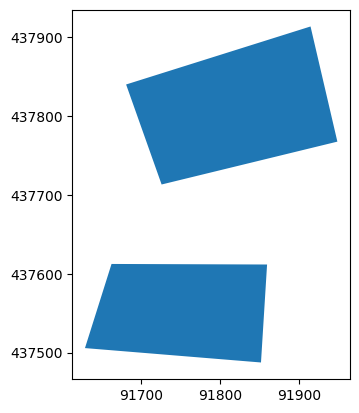

In [9]:
gdf.plot()

#### Exercise 5<a name="ex5"></a>

Plot the locations of the traffic measurements from exercise 4.

<a href="#ans5">Answer Exercise 5</a>

#### Exercise 6<a name="ex6"></a>

The plot in exercise 5 doesn't look very appealing. This is caused by an error in one of the latitude coördinates. Remove the points with the wrong coördinates.

<a href="#ans6">Answer Exercise 6</a>


## 6. [Add a basemap](#top)<a id="7"></a>

You can add a basemap to your plot with the `contextily` package. You can install `contextily` with:<br><br>

`pip install contextily`.

Add a basemap using the following steps:
1. convert the coördinate reference system (crs) of your `GeoDataFrame` to lat/lon coördinates.
2. plot the `GeoDataFrame` with `gdf.plot()`
3. use the `add_basemap` function from the `contextily` package to add a basemap to the plot

In [10]:
import contextily as ctx

## 6.1 convert crs

`contextily` requires a specific coördinate reference system (epsg 3857). Therefore we need to convert the crs from our `GeoDataFrame` to epsg 3857. This is easily done with the `to_crs` method. If your current `GeoDataFrame` has no crs the `to_crs` method won't work and you have to specify the `crs` first. The current crs is an attribute of your `GeoDataFrame`: `gdf.crs`.

In [11]:
print(gdf.crs)
gdf = gdf.to_crs(epsg=3857)

EPSG:28992


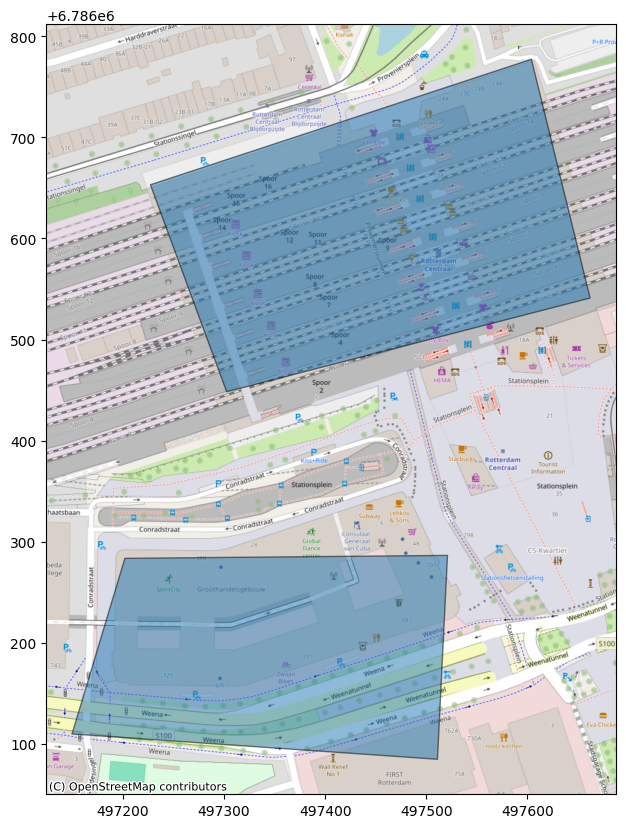

In [12]:
ax = gdf.plot(figsize=(10, 10), alpha=0.5, edgecolor='k')
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

#### Exercise 7<a name="ex7"></a>

When we created the `GeoDataFrame` from the `DataFrame` of the traffic measurements we didn't specify a coordinate reference system (crs). In order to plot a background map we need to convert the `GeoDataFrame` to a certain crs. Therefore we have to specify the original crs. Specify the crs when creating the `GeoDataFrame` of the traffic measurements, then convert the crs and plot a background map. The crs of the original `latitude` and `longitude` have epsg number 4326. 

<a href="#ans7">Answer Exercise 7</a>

#### Exercise 8<a name="ex8"></a>
use the `column` and `legend` arguments of the `GeoDataFrame.plot` method to color the points based on the traffic intensity, defined by the 'Waarde' column. 

<a href="#ans8">Answer Exercise 8</a>


## Answers

#### <a href="#ex1">Answer exercise 1</a> <a name="ans1"></a>

This shapefile contains the boundaries of the boroughs of New York.

In [13]:
gdf_nybb = gpd.read_file(r'data/nybb.shp')
gdf_nybb.head()

,BoroCode,BoroName,Shape_Leng,Shape_Area,geometry
0,5,Staten Island,330454.175933,1.623847e+09,"MULTIPOLYGON (((970217.022 145643.332, 970227...."
1,3,Brooklyn,741227.337073,1.937810e+09,"MULTIPOLYGON (((1021176.479 151374.797, 102100..."
2,4,Queens,896875.396449,3.045079e+09,"MULTIPOLYGON (((1029606.077 156073.814, 102957..."
3,1,Manhattan,358400.912836,6.364308e+08,"MULTIPOLYGON (((981219.056 188655.316, 980940...."
4,2,Bronx,464475.145651,1.186822e+09,"MULTIPOLYGON (((1012821.806 229228.265, 101278..."


#### <a href="#ex2">Answer exercise 2</a> <a name="ans2"></a>
Queens has the biggest surface area.

In [14]:
gdf_nybb.loc[gdf_nybb['Shape_Area'].idxmax()]

BoroCode                                                      4
BoroName                                                 Queens
Shape_Leng                                        896875.396449
Shape_Area                                        3045079488.63
geometry      MULTIPOLYGON (((1029606.0765991211 156073.8142...
Name: 2, dtype: object

#### <a href="#ex3">Answer exercise 3</a> <a name="ans3"></a>

In [15]:
gdf_turbines['EIGENAAR'].unique()

array(['Gemini Buitengaats', 'PAWP: Eneco Windmolens Offshore BV.',
       'Luchterduinen: Q10 Offshore Wind BV.', 'Noordzeewind',
       'Gemini ZeeEnergie'], dtype=object)

#### <a href="#ex4">Answer exercise 4</a> <a name="ans4"></a>

In [16]:
df_verkeer = pd.read_csv(r'data/traffic_intensity_Utrecht.csv')
geometry = gpd.points_from_xy(df_verkeer['longitude'], df_verkeer['latitude'])
gdf_verkeer = gpd.GeoDataFrame(df_verkeer.copy(), geometry=geometry)
gdf_verkeer.head()

,Vri,longitude,latitude,Detector,Waarde,geometry
0,1,5.142973,52.095821,45.2,5089,POINT (5.14297 52.09582)
1,1,5.143134,52.095817,4.3,87522,POINT (5.14313 52.09582)
2,1,5.143140,52.095881,5.3,97708,POINT (5.14314 52.09588)
3,1,5.143177,52.095821,4.2,87686,POINT (5.14318 52.09582)
4,1,5.143182,52.095885,5.2,97366,POINT (5.14318 52.09589)


#### <a href="#ex5">Answer exercise 5</a> <a name="ans5"></a>

<Axes: >

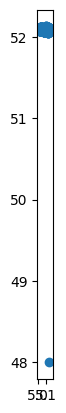

In [17]:
gdf_verkeer.plot()

#### <a href="#ex6">Answer exercise 6</a> <a name="ans6"></a>

<Axes: >

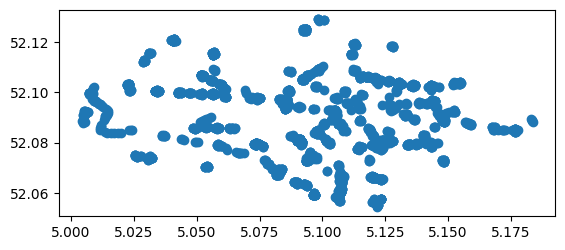

In [18]:
gdf_verkeer = gdf_verkeer[gdf_verkeer.latitude!=gdf_verkeer.latitude.min()]
gdf_verkeer.plot()

#### <a href="#ex7">Answer exercise 7</a> <a name="ans7"></a>

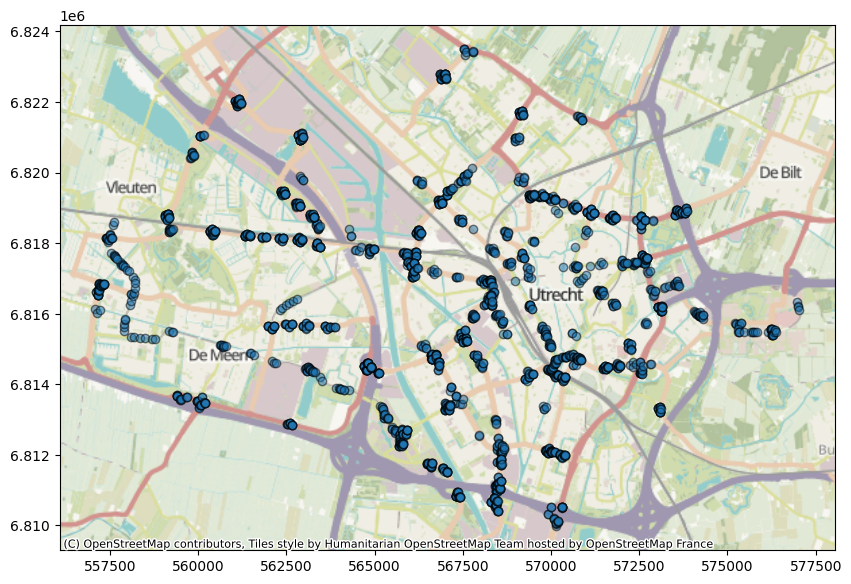

In [19]:
gdf_verkeer = gpd.GeoDataFrame(df_verkeer.copy(), geometry=geometry, crs=4326)
gdf_verkeer = gdf_verkeer[gdf_verkeer.latitude!=gdf_verkeer.latitude.min()]
gdf_verkeer = gdf_verkeer.to_crs(epsg=3857)
ax = gdf_verkeer.plot(figsize=(10, 10), alpha=0.5, edgecolor='k')
ctx.add_basemap(ax)

#### <a href="#ex8">Answer exercise 8</a> <a name="ans8"></a>

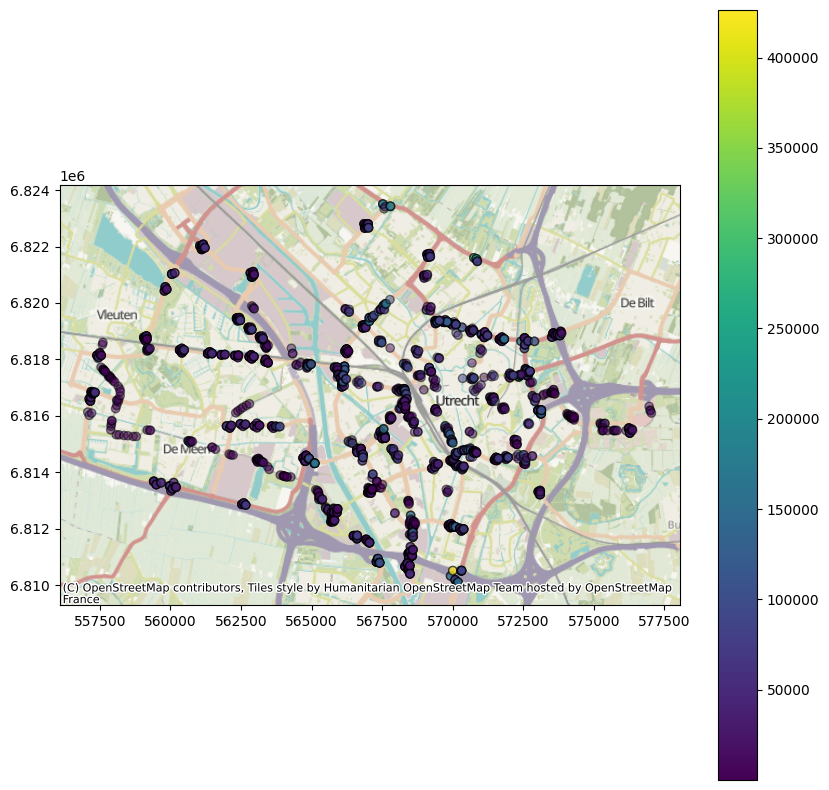

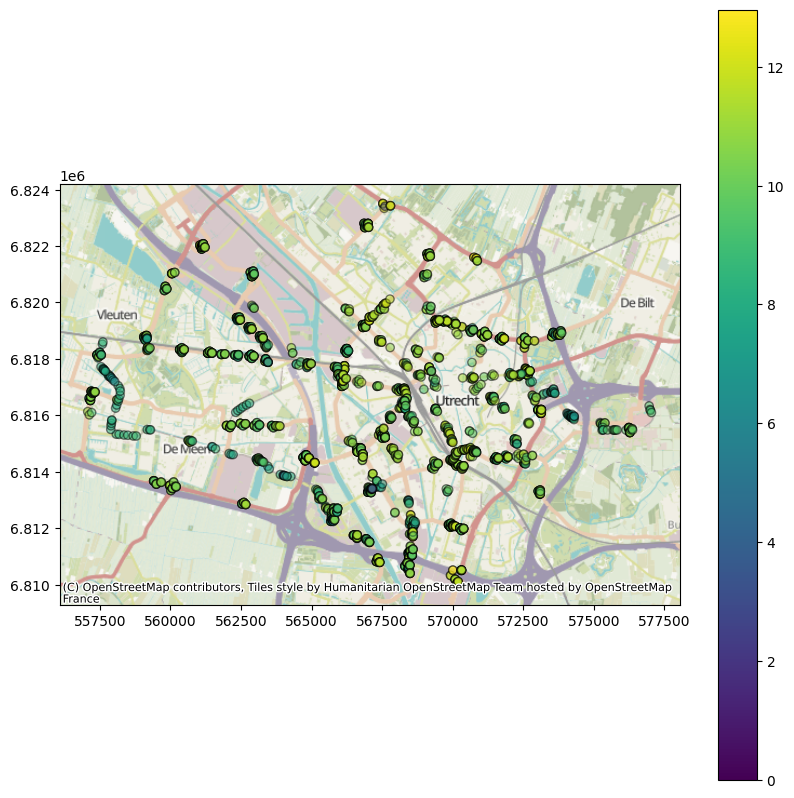

In [20]:
ax = gdf_verkeer.plot('Waarde', legend=True, figsize=(10, 10), alpha=0.5, edgecolor='k')
ctx.add_basemap(ax)

#bonus plot the log value
import numpy as np
gdf_verkeer['logWaarde'] = np.log(gdf_verkeer['Waarde'])
ax = gdf_verkeer.plot('logWaarde', legend=True, figsize=(10, 10), alpha=0.5, edgecolor='k')
ctx.add_basemap(ax)

### Origin of the data
* traffic intensity data 'intensity_day.csv' from Utrecht obtained from https://data.overheid.nl/dataset/verkeer-tellingen-verkeerslichten-2015